In [1]:
# Basic libraries for data handling
import os
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Audio processing library
import librosa
import librosa.display

# To play audio inside notebook
import IPython.display as ipd

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

In [5]:
import os
os.chdir("..")

In [6]:
import sys
print(sys.executable)

c:\Heart_Disease\venv\Scripts\python.exe


In [7]:
# Add project root path so we can import config.py
import sys
sys.path.append("..")

# Import configuration file
import config

In [10]:
# Load CSV file containing filenames and labels
df = pd.read_csv(config.CSV_PATH)

# Display first 5 rows
df.head(10)

,Gender,Heart Sound Type,Location,Heart Sound ID
0,F,Normal,RC,F_N_RC
1,F,Normal,LC,F_N_LC
2,M,Normal,RUSB,M_N_RUSB
3,F,Normal,LUSB,F_N_LUSB
4,F,Normal,LLSB,F_N_LLSB
5,F,Normal,Apex,F_N_A
6,M,Late Diastolic Murmur,LC,M_LDM_LC
7,M,Mid Systolic Murmur,Apex,M_MSM_A
8,F,Normal,RUSB,F_N_RUSB
9,F,Mid Systolic Murmur,Apex,F_MSM_A


In [9]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            50 non-null     str  
 1   Heart Sound Type  50 non-null     str  
 2   Location          50 non-null     str  
 3   Heart Sound ID    50 non-null     str  
dtypes: str(4)
memory usage: 1.7 KB


In [11]:
# Statistical summary (for numeric columns)
df.describe()

,Gender,Heart Sound Type,Location,Heart Sound ID
count,50,50,50,50
unique,2,10,6,50
top,F,Normal,LUSB,F_N_RC
freq,26,9,13,1


In [12]:
# Check if any missing values exist
df.isnull().sum()

Gender              0
Heart Sound Type    0
Location            0
Heart Sound ID      0
dtype: int64

In [14]:
# Create filename column from Heart Sound ID
df['filename'] = df['Heart Sound ID'] + ".wav"

df.head()

,Gender,Heart Sound Type,Location,Heart Sound ID,filename
0,F,Normal,RC,F_N_RC,F_N_RC.wav
1,F,Normal,LC,F_N_LC,F_N_LC.wav
2,M,Normal,RUSB,M_N_RUSB,M_N_RUSB.wav
3,F,Normal,LUSB,F_N_LUSB,F_N_LUSB.wav
4,F,Normal,LLSB,F_N_LLSB,F_N_LLSB.wav


In [15]:
# Count each heart condition
df['Heart Sound Type'].value_counts()

Heart Sound Type
Normal                   9
Mid Systolic Murmur      7
Late Diastolic Murmur    6
Early Systolic Murmur    6
Late Systolic Murmur     5
S3                       5
Atrial Fibrillation      4
Tachycardia              3
AV Block                 3
S4                       2
Name: count, dtype: int64

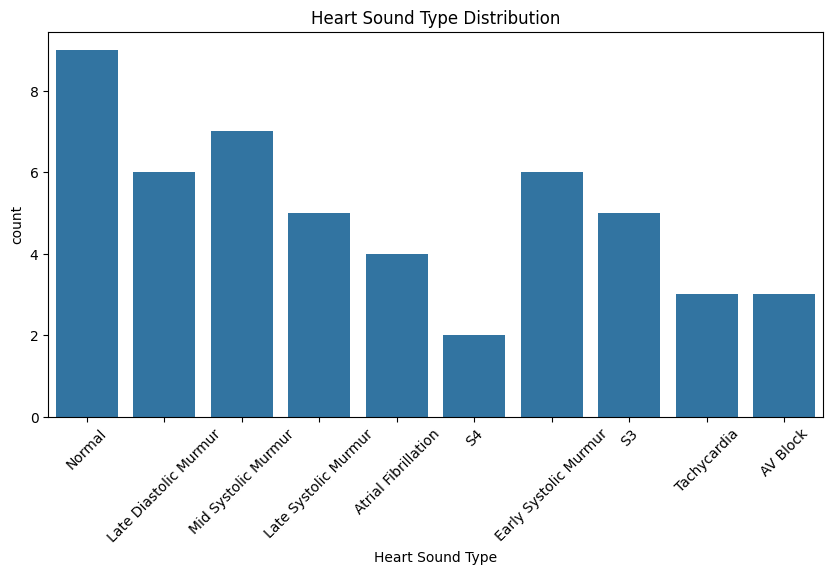

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x='Heart Sound Type', data=df)

plt.xticks(rotation=45)
plt.title("Heart Sound Type Distribution")

plt.show()

In [17]:
# Normal → 0
# Abnormal → 1

df['binary_label'] = df['Heart Sound Type'].apply(
    lambda x: 0 if x == 'Normal' else 1
)

df.head()

,Gender,Heart Sound Type,Location,Heart Sound ID,filename,binary_label
0,F,Normal,RC,F_N_RC,F_N_RC.wav,0
1,F,Normal,LC,F_N_LC,F_N_LC.wav,0
2,M,Normal,RUSB,M_N_RUSB,M_N_RUSB.wav,0
3,F,Normal,LUSB,F_N_LUSB,F_N_LUSB.wav,0
4,F,Normal,LLSB,F_N_LLSB,F_N_LLSB.wav,0


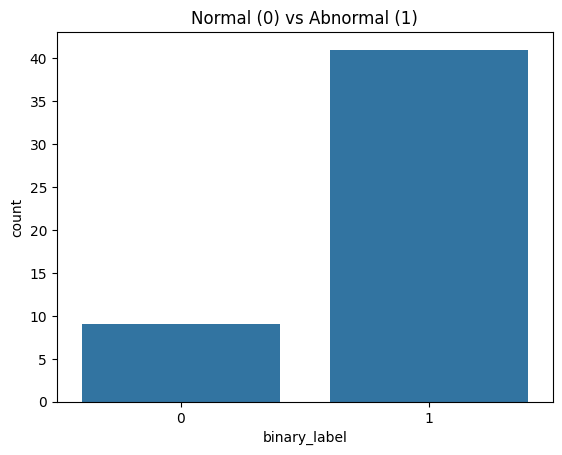

In [18]:
sns.countplot(x='binary_label', data=df)

plt.title("Normal (0) vs Abnormal (1)")
plt.show()

In [19]:
df['binary_label'].value_counts(normalize=True)

binary_label
1    0.82
0    0.18
Name: proportion, dtype: float64

In [20]:
missing_files = []

for file in df['filename']:
    path = os.path.join(config.DATA_PATH, file)
    
    if not os.path.exists(path):
        missing_files.append(file)

print("Missing files:", len(missing_files))

Missing files: 0


In [21]:
sample_file = df.iloc[0]['filename']
file_path = os.path.join(config.DATA_PATH, sample_file)

y, sr = librosa.load(file_path, sr=config.SAMPLE_RATE)

print("Sample Rate:", sr)
print("Duration:", len(y)/sr)

ipd.Audio(y, rate=sr)

Sample Rate: 22050
Duration: 15.0


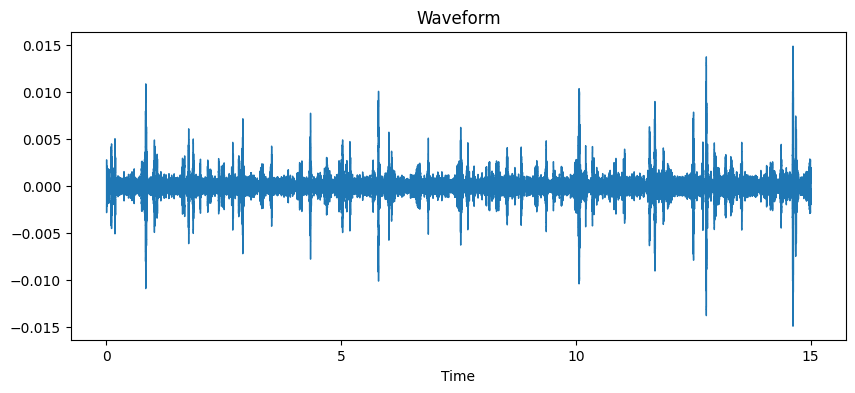

In [22]:
plt.figure(figsize=(10,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.show()

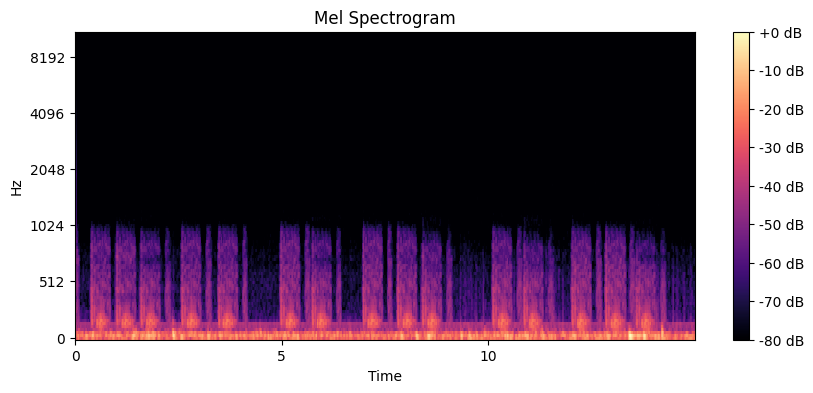

In [25]:
# Convert audio to Mel Spectrogram
S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=config.N_MELS
)

# Convert to decibel scale
S_db = librosa.power_to_db(S, ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10,4))

librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.show()

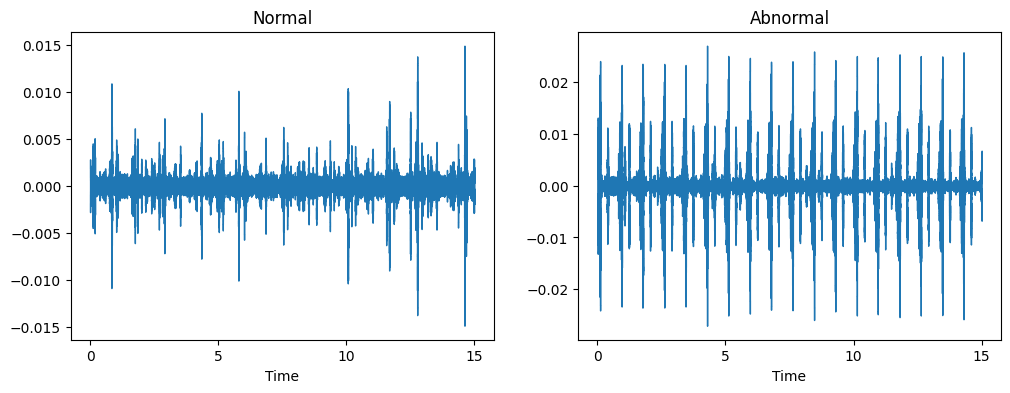

In [24]:
# Get one normal and one abnormal sample
normal_file = df[df['binary_label'] == 0].iloc[0]['filename']
abnormal_file = df[df['binary_label'] == 1].iloc[0]['filename']

# Load both audio files
y1, sr1 = librosa.load(os.path.join(config.DATA_PATH, normal_file))
y2, sr2 = librosa.load(os.path.join(config.DATA_PATH, abnormal_file))

# Plot side-by-side comparison
plt.figure(figsize=(12,4))

# Normal waveform
plt.subplot(1,2,1)
librosa.display.waveshow(y1, sr=sr1)
plt.title("Normal")

# Abnormal waveform
plt.subplot(1,2,2)
librosa.display.waveshow(y2, sr=sr2)
plt.title("Abnormal")

plt.show()

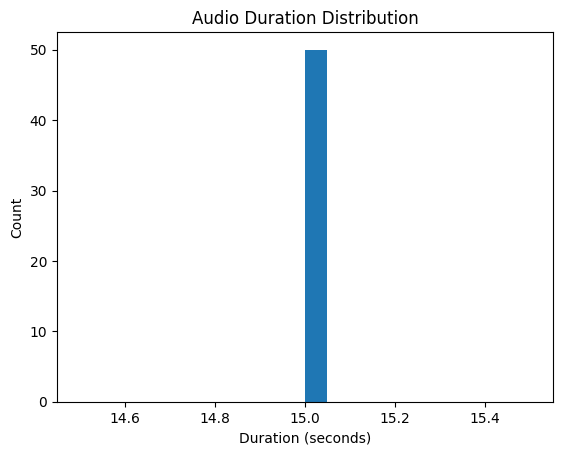

Min duration: 15.0
Max duration: 15.0


In [23]:
# Store duration of each audio file
durations = []

for file in df['filename']:
    y, sr = librosa.load(os.path.join(config.DATA_PATH, file))
    
    # Convert samples to seconds
    durations.append(len(y)/sr)

# Plot distribution
plt.hist(durations, bins=20)

plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")

plt.show()

# Print stats
print("Min duration:", np.min(durations))
print("Max duration:", np.max(durations))